In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
%matplotlib widget

In [7]:
dfdall = pd.read_csv("Output_Factor_6FFF_detector_no-movement-test_2_2026-04-19_14-35-36.csv", skiprows = 35)

In [8]:
def getpulses(df, threshold=0.2):
    df = df.loc[:,['Time', 'ch0', 'ch1']]
    lasttime = df.iloc[-1,0]
    zeros = df.loc[(df.Time < 1)|(df.Time > (lasttime -1)), ['ch0', 'ch1']].mean()
    dfzeros = df.loc[:, ['ch0', 'ch1']] - zeros
    dfzeros.columns = ['ch0z', 'ch1z']
    dfz = pd.concat([df, dfzeros], axis=1)
    firstpulsetime = dfz.loc[dfz.ch0.diff() > 1, 'Time'].min()
    lastpulsetime =  dfz.loc[dfz.ch0.diff() > 1, 'Time'].max()
    maxch0_nolight = dfz.loc[(dfz.Time < firstpulsetime - 0.2)|(dfz.Time > lastpulsetime + 0.2), 'ch0z'].max()
    maxch0_nolight_margin =  maxch0_nolight * (1 + threshold)
    dfz['pulse'] = dfz.ch0z > maxch0_nolight_margin
    dfz['pulse'] = dfz.pulse.astype("boolean")
    dfz['next_pulse'] = dfz.pulse.shift(-1)
    dfz['ch0z_pomp'] = dfz.ch0z * 1
    dfz['next_ch0z'] = dfz.ch0z_pomp.shift(-1)
    dfz['pulse_coincide'] = dfz.pulse & dfz.next_pulse
    dfz['pulse_coincide_after'] = dfz.pulse_coincide.shift()
    dfz['ch0zcomplete'] = dfz.ch0z
    dfz.loc[dfz.pulse_coincide, 'ch0zcomplete'] = dfz.ch0z + dfz.next_ch0z
    dfz.loc[dfz.pulse_coincide_after, 'ch0zcomplete']=0
    dfz['single_pulse'] = dfz.pulse & ~dfz.pulse_coincide_after
    return dfz.loc[:,['Time', 'ch0', 'ch1', 'ch0z', 'ch1z', 'single_pulse', 'pulse_coincide', 'ch0zcomplete']]

In [9]:
def getpulsesscan(df, threshold=0.2):
    df = df.loc[:,['Time', 'X', 'ch0', 'ch1']]
    lasttime = df.iloc[-1,0]
    zeros = df.loc[(df.Time < 1)|(df.Time > (lasttime -1)), ['ch0', 'ch1']].mean()
    dfzeros = df.loc[:, ['ch0', 'ch1']] - zeros
    dfzeros.columns = ['ch0z', 'ch1z']
    dfz = pd.concat([df, dfzeros], axis=1)
    firstpulsetime = dfz.loc[dfz.ch0.diff() > 1, 'Time'].min()
    lastpulsetime =  dfz.loc[dfz.ch0.diff() > 1, 'Time'].max()
    maxch0_nolight = dfz.loc[(dfz.Time < firstpulsetime - 0.2)|(dfz.Time > lastpulsetime + 0.2), 'ch0z'].max()
    maxch0_nolight_margin =  maxch0_nolight * (1 + threshold)
    dfz['pulse'] = dfz.ch0z > maxch0_nolight_margin
    dfz['pulse'] = dfz.pulse.astype("boolean")
    dfz['next_pulse'] = dfz.pulse.shift(-1)
    dfz['ch0z_pomp'] = dfz.ch0z * 1
    dfz['next_ch0z'] = dfz.ch0z_pomp.shift(-1)
    dfz['pulse_coincide'] = dfz.pulse & dfz.next_pulse
    dfz['pulse_coincide_after'] = dfz.pulse_coincide.shift()
    dfz['ch0zcomplete'] = dfz.ch0z
    dfz.loc[dfz.pulse_coincide, 'ch0zcomplete'] = dfz.ch0z + dfz.next_ch0z
    dfz.loc[dfz.pulse_coincide_after, 'ch0zcomplete']=0
    dfz['single_pulse'] = dfz.pulse & ~dfz.pulse_coincide_after
    return dfz.loc[:,['Time', 'X', 'ch0', 'ch1', 'ch0z', 'ch1z', 'single_pulse', 'pulse_coincide', 'ch0zcomplete']]

In [10]:
def syncpulses(dfd, dfr):
    dft = dfd.copy()
    dft["single_pulse_reference"] = False
    dft["ch0zcomplete_reference"] = np.nan
    dft["pulse_coincide_reference"] = False
    mask = dft.single_pulse
    #This only works if there is the same number of single pulses in both data frames
    results = dfr.loc[dfr.single_pulse, ['single_pulse', 'ch0zcomplete', 'pulse_coincide']].to_numpy()
    dft.loc[mask, 'single_pulse_reference'] = results[:, 0].astype(bool)
    dft.loc[mask, 'ch0zcomplete_reference'] = results[:, 1].astype(float)
    dft.loc[mask, 'pulse_coincide_reference'] = results[:, 2].astype(bool)
    dft['ratio'] = dft.ch0zcomplete / dft.ch0zcomplete_reference
    return dft

In [11]:
dfdp = getpulses(dfdall)

In [12]:
dfrall = pd.read_csv("Output_Factor_6FFF_reference_no-movement-test_2_2026-04-19_14-35-29.csv", skiprows=33)

In [13]:
dfrp = getpulses(dfrall)

In [14]:
dfrp.single_pulse.sum() == dfdp.single_pulse.sum()

np.True_

In [15]:
dft = syncpulses(dfdp, dfrp)

In [16]:
dft

,Time,ch0,ch1,ch0z,ch1z,single_pulse,pulse_coincide,ch0zcomplete,single_pulse_reference,ch0zcomplete_reference,pulse_coincide_reference,ratio
0,0.009451,-7.238125,-6.984063,0.080149,0.189948,False,False,0.080149,False,NaN,False,NaN
1,0.010238,-7.296563,-7.261250,0.021711,-0.087240,False,False,0.021711,False,NaN,False,NaN
2,0.011025,-7.348438,-7.091563,-0.030164,0.082448,False,False,-0.030164,False,NaN,False,NaN
3,0.011811,-7.272813,-7.097500,0.045461,0.076510,False,False,0.045461,False,NaN,False,NaN
4,0.012599,-7.259062,-7.125312,0.059211,0.048698,False,False,0.059211,False,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
133616,105.195812,-7.325938,-7.243750,-0.007664,-0.069740,False,False,-0.007664,False,NaN,False,NaN
133617,105.196599,-7.220000,-7.180000,0.098274,-0.005990,False,False,0.098274,False,NaN,False,NaN
133618,105.197386,-7.276875,-7.202500,0.041399,-0.028490,False,False,0.041399,False,NaN,False,NaN
133619,105.198174,-7.351250,-7.168125,-0.032976,0.005885,False,False,-0.032976,False,NaN,False,NaN


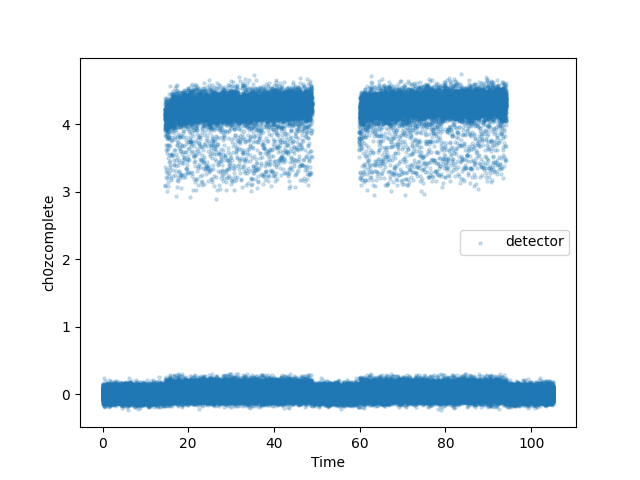

In [17]:
ax1 = dft.plot.scatter(x='Time', y='ch0zcomplete', marker='.', alpha=0.2, label='detector')

In [18]:
dft.plot.scatter(x='Time', y='ch0zcomplete_reference', marker='.', color='red', ax=ax1, label='reference', alpha=0.2)

<Axes: xlabel='Time', ylabel='ch0zcomplete_reference'>

In [19]:
dft.plot.scatter(x='Time', y='ratio', marker='.', color='green', ax=ax1, label='ratio', alpha=0.2, grid=True)

<Axes: xlabel='Time', ylabel='ratio'>

In [20]:
ax1.set_title("Detector and Reference No movement")

Text(0.5, 1.0, 'Detector and Reference No movement')

In [21]:
ax1.set_ylabel('Voltage in 30pF capacitor (V)')

Text(55.847222222222214, 0.5, 'Voltage in 30pF capacitor (V)')

In [22]:
ax1.set_xlabel('time (s)')

Text(0.5, 23.52222222222222, 'time (s)')

## 6FFF 10x10 profile crossline 5 mm/s with reference

In [23]:
dfd5 = pd.read_csv("6FFF_detector_scan_air_10x10_6x_crossline_dmax_5mm-s_10.0x10.0_Profile_X_Depth-14.0_continuous_Speed-25.0_2026-04-19_15-01-45.csv", skiprows=43)

/tmp/ipykernel_5137/1080905375.py:1: DtypeWarning: Columns (0: pulse, 1: pulse_after, 2: pulse_coincide, 3: single_pulse, 4: pulse_coincide_after) have mixed types. Specify dtype option on import or set low_memory=False.
  dfd5 = pd.read_csv("6FFF_detector_scan_air_10x10_6x_crossline_dmax_5mm-s_10.0x10.0_Profile_X_Depth-14.0_continuous_Speed-25.0_2026-04-19_15-01-45.csv", skiprows=43)


In [24]:
dfd5.plot.scatter(x='Time', y='ch0')

<Axes: xlabel='Time', ylabel='ch0'>

In [25]:
dfdp5 = getpulsesscan(dfd5)

In [26]:
dfdp5.single_pulse.sum()

np.int64(9134)

In [27]:
dfr5 = pd.read_csv("Output_Factor_6FFF_reference_air_scan_10x10_6x_crossline_dmax_5mm-s_2026-04-19_15-01-39.csv", skiprows = 33)

In [28]:
dfrp5 = getpulses(dfr5)

In [29]:
dfrp5.single_pulse.sum()

np.int64(15280)

<Axes: xlabel='Time', ylabel='ch0'>

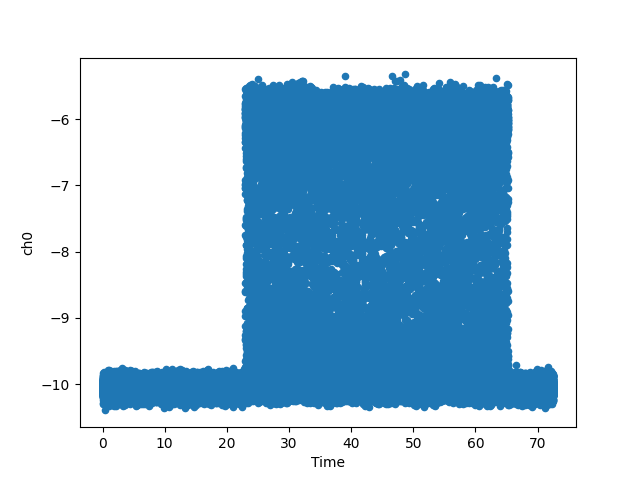

In [30]:
dfr5.plot.scatter(x='Time', y='ch0')

In [31]:
dfdp5.loc[:,['Time', 'single_pulse', 'ch0zcomplete']].to_csv("dfd.csv", index=False)

In [32]:
dfrp5.loc[:,['Time', 'single_pulse', 'ch0zcomplete']].to_csv("dfr.csv", index=False)